# System

7-qubit, 30-layer system.

The VQE config is:

```JSON
"config":{"run":"vqe","nqubits":7,"state":"dmatrix","output":{"file_name_prefix":"xy_ansatz_time_depol_1e-3_tmax_3","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"ising","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":<SWEEPING ACROSS VARIOUS T_MAX>}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"time-depol","noise_prob":[0,0,0.001,0.0],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}

```

---

# Import

In [26]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [27]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,   # ✓ already here
"ytick.labelsize":  8,   # ✓ already here
"axes.labelsize":   8,   # ← add this (xlabel / ylabel)
"legend.fontsize":  8,   # ← add this (legend text)
"font.size":        8,   # ← add this (global fallback)
})

# Variables

In [28]:
# Usage
BASE_DIR = "data/7Q-various-tmax"
# "exact_sol":-8.56677223350563
EXACT_SOL: float = -8.56677223350563

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "reports/7Q-various-tmax/"

---

# Raw Data Processing Before Plotting

In [29]:
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
RAW_SIM_DATA.keys()

dict_keys(['7Q_tmax_sweep_ising_depol_tmax100_20260726_094558', '7Q_tmax_sweep_ising_depol_tmax40_20260725_174225', '7Q_tmax_sweep_ising_depol_tmax10_20260725_063219', '7Q_tmax_sweep_ising_depol_tmax20_20260725_110811', '7Q_tmax_sweep_ising_depol_tmax5_20260724_220628', '7Q_tmax_sweep_ising_depol_tmax15_20260725_083518', '7Q_tmax_sweep_ising_depol_tmax1_20260724_191844', '7Q_tmax_sweep_ising_depol_tmax30_20260725_140326', '7Q_tmax_sweep_ising_depol_tmax8_20260725_034710', '7Q_tmax_sweep_ising_depol_tmax50_20260725_204517', '7Q_tmax_sweep_ising_depol_tmax60_20260725_234212', '7Q_tmax_sweep_ising_depol_tmax80_20260726_040144', '7Q_tmax_sweep_ising_depol_tmax3_20260724_205142'])

In [30]:
def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}
        
        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noise_off", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue
        
        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (mul1, ric2, etc.) ---
        zne_folder = content.get("ZNE", {})
        
        # If mul1 is missing, ensure the key exists in the raw zne_folder
        for label, runs in zne_folder.items():
            ext_vals, all_y_curves = [], []
            noise_levels = None
            
            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run: 
                    continue
                
                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})
                
                tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]

                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                zne_cost = others.get("cost_richardson_zne")

                if current_y and current_n and ext_val is not None:
                    ext_vals.append(ext_val)
                    all_y_curves.append(current_y)
                    if noise_levels is None:
                        noise_levels = current_n
                else:
                    # Debug print to see which file is failing the check
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing", 
                    "tmax":           tmax,
                    "exact_sol":      EXACT_SOL, # Global variable
                    "order":           len(noise_levels)-1,
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"],
                    "zne_cost_mean":   float(np.mean(zne_cost)) if zne_cost else None,
                    "zne_cost_std":    float(np.std(zne_cost)) if zne_cost else None
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

def process_raw_zne_vs_tmax_plotting(raw_data: dict) -> dict:
    processed = {}
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        zne_folder = content.get("ZNE", {})

        for label, runs in zne_folder.items():
            if label != "ric3":  # ← only process ric4
                continue

            tmax_opt_list = []
            ext_val_list  = []

            for k, run in runs.items():
                if not run or "REDUNDANT" in k or "output" not in run:
                    continue
                try:
                    initial_tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                    tmax_opt     = run["config"]["init_param"]["value"][29]
                    ext_val      = run["output"]["zne_values"].get("extrapolated_value")

                    if ext_val is not None:
                        tmax_opt_list.append(tmax_opt)
                        ext_val_list.append(ext_val)
                    else:
                        print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing extrapolated_value.")

                except (KeyError, IndexError, TypeError) as e:
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: {e}")
                    continue

            if tmax_opt_list:
                processed.setdefault(exp_name, {})[label] = {
                    "initial_tmax": initial_tmax,
                    "tmax_opt":     tmax_opt_list,
                    "zne":          ext_val_list,
                }
            else:
                print(f"❌ No valid runs for {exp_name}/{label}")

    return processed

def process_raw_vqe_noiseoff_vs_tmax_plotting(raw_data: dict) -> dict:
    processed = {}
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        nf_folder = content.get("VQE_noise_off", {})

        tmax_opt_list = []
        cost_list     = []

        for k, run in nf_folder.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue
            try:
                initial_tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                tmax_opt     = run["output"]["optimized_parameters"][0][29]
                cost         = run["output"]["optimized_minimum_cost"][0]

                tmax_opt_list.append(tmax_opt)
                cost_list.append(cost)

            except (KeyError, IndexError, TypeError) as e:
                print(f"⚠️ Skipping {exp_name}/{k}: {e}")
                continue

        if tmax_opt_list:
            processed[exp_name] = {
                "initial_tmax": initial_tmax,
                "tmax_opt":     tmax_opt_list,
                "cost":         cost_list,
            }
        else:
            print(f"❌ No valid runs for {exp_name}")

    return processed

In [31]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

dict_keys(['7Q_tmax_sweep_ising_depol_tmax100_20260726_094558', '7Q_tmax_sweep_ising_depol_tmax40_20260725_174225', '7Q_tmax_sweep_ising_depol_tmax10_20260725_063219', '7Q_tmax_sweep_ising_depol_tmax20_20260725_110811', '7Q_tmax_sweep_ising_depol_tmax5_20260724_220628', '7Q_tmax_sweep_ising_depol_tmax15_20260725_083518', '7Q_tmax_sweep_ising_depol_tmax1_20260724_191844', '7Q_tmax_sweep_ising_depol_tmax30_20260725_140326', '7Q_tmax_sweep_ising_depol_tmax8_20260725_034710', '7Q_tmax_sweep_ising_depol_tmax50_20260725_204517', '7Q_tmax_sweep_ising_depol_tmax60_20260725_234212', '7Q_tmax_sweep_ising_depol_tmax80_20260726_040144', '7Q_tmax_sweep_ising_depol_tmax3_20260724_205142'])

In [32]:
PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax10_20260725_063219"]["ric3"]

{'noise_type': 'depolarizing',
 'tmax': 10.0,
 'exact_sol': -8.56677223350563,
 'order': 3,
 'sorted_noise': [1, 3, 5, 7],
 'mean_exp_vals': [-7.991460778560127,
  -7.210863422547369,
  -6.510282447587352,
  -5.881190910433974],
 'std_exp_vals': [0.07626670993611862,
  0.14878723459807247,
  0.21006073787456225,
  0.25867909293227703],
 'zne_mean': -8.414430269225688,
 'zne_std': 0.04601865166869637,
 'mean_noise_off': -8.429980216744722,
 'std_noise_off': 0.04827693260093841,
 'zne_cost_mean': 11.390625,
 'zne_cost_std': 0.0}

---

# Plotting

## Plot: 4-point ZNE for Various Tmax Values

In [33]:
def plot_zne_vs_tmax(
    data: dict,
    title: str = "ZNE vs tmax",
    figsize: tuple = (7, 4.5),
    save_dir: str = "reports",
    file_type: str = "png",
    file_name: str = "zne_vs_tmax",
    dpi: int = 600
):
    """
    Plot ZNE mean ± std vs tmax — journal-ready style.
    """
    tmax_vals, zne_means, zne_stds, noise_off_means, noise_off_stds = [], [], [], [], []

    for tmax_key, inner in sorted(data.items(), key=lambda x: int(x[0].replace("tmax", ""))):
        entry = next(iter(inner.values()))
        tmax_vals.append(entry["tmax"])
        zne_means.append(entry["zne_mean"])
        zne_stds.append(entry["zne_std"])

        # Noise off
        noise_off_means.append(entry.get("mean_noise_off"))  # ← append
        noise_off_stds.append(entry.get("std_noise_off"))    # ← append

    tmax_vals = np.array(tmax_vals)
    zne_means = np.array(zne_means)
    zne_stds  = np.array(zne_stds)
    noise_off_means = np.array(noise_off_means)
    noise_off_stds  = np.array(noise_off_stds)

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        tmax_vals, zne_means,
        yerr=zne_stds,
        fmt="o-",
        capsize=4,
        linewidth=1.2,
        markersize=5,
        markerfacecolor="white",
        markeredgewidth=1.2,
        color="#2563eb",
        ecolor="#2563eb",
        elinewidth=1.0,
        label="ZNE mean ± std",
    )

    # Noise off with errorbars to match ZNE style
    ax.errorbar(
        tmax_vals, noise_off_means,
        yerr=noise_off_stds,           # ← add std as errorbars
        fmt="s-",                      # ← square markers with line
        capsize=4,
        linewidth=1.2,
        markersize=5,
        markerfacecolor="white",       # ← open markers, consistent with ZNE
        markeredgewidth=1.2,
        color="green",
        ecolor="green",
        elinewidth=1.0,
        label="Noise-off± std",  # ← updated label
    )

    exact_sol = entry["exact_sol"]
    ax.axhline(
        exact_sol,
        color="#dc2626",
        linewidth=1.2,
        linestyle="--",
        label=f"Exact solution: {exact_sol:.4f}",
    )

    ax.set_xlabel(r"Initial $T_{\text{max}}$", fontsize=8)
    ax.set_ylabel("VQE / ZNE (4-point)",               fontsize=8)

    ax.legend(
        fontsize=8,
        frameon=False,
        framealpha=1.0,
        edgecolor="0.5",
        fancybox=False,
    )

    ax.grid(True, which="major", linestyle=":", linewidth=0.5, color="0.75", zorder=0)
    ax.set_axisbelow(True)

    fig.tight_layout(pad=0.5)

    os.makedirs(save_dir, exist_ok=True)
    file_type = file_type.lower().replace(".", "")
    out_path  = os.path.join(save_dir, f"{file_name}.{file_type}")
    fig.savefig(out_path, dpi=dpi)

    print(f"Saved → {out_path}")
    plt.show()

In [34]:
#plot_zne_vs_tmax(PROCESSED_SIM_DATA, save_dir= MASTER_EXPORT_DIR, file_name="RESULT-ZNE-VS-TMAX-IEEE", figsize= FIG_SIZE_IEEE_DOUBLE, dpi=600)

---
ZNE vs optimized tmax raw values plotting

In [35]:
sorted(PROCESSED_SIM_DATA.keys())

['7Q_tmax_sweep_ising_depol_tmax100_20260726_094558',
 '7Q_tmax_sweep_ising_depol_tmax10_20260725_063219',
 '7Q_tmax_sweep_ising_depol_tmax15_20260725_083518',
 '7Q_tmax_sweep_ising_depol_tmax1_20260724_191844',
 '7Q_tmax_sweep_ising_depol_tmax20_20260725_110811',
 '7Q_tmax_sweep_ising_depol_tmax30_20260725_140326',
 '7Q_tmax_sweep_ising_depol_tmax3_20260724_205142',
 '7Q_tmax_sweep_ising_depol_tmax40_20260725_174225',
 '7Q_tmax_sweep_ising_depol_tmax50_20260725_204517',
 '7Q_tmax_sweep_ising_depol_tmax5_20260724_220628',
 '7Q_tmax_sweep_ising_depol_tmax60_20260725_234212',
 '7Q_tmax_sweep_ising_depol_tmax80_20260726_040144',
 '7Q_tmax_sweep_ising_depol_tmax8_20260725_034710']

In [36]:
RAW_ZNE_VS_TMAX_DATA = process_raw_zne_vs_tmax_plotting(RAW_SIM_DATA)
RAW_ZNE_VS_TMAX_DATA["7Q_tmax_sweep_ising_depol_tmax10_20260725_063219"].keys()

dict_keys(['ric3'])

In [52]:
# Init Tmax = 80
RAW_ZNE_VS_TMAX_DATA["7Q_tmax_sweep_ising_depol_tmax80_20260726_040144"]["ric3"]

{'initial_tmax': 80.0,
 'tmax_opt': [75.01945598139497,
  70.066954966491,
  77.67787334976173,
  77.7513183648989,
  72.63868788726423,
  73.32056312458843,
  77.9041114570747,
  78.00152502344059,
  79.50675617533575,
  77.7462508933041],
 'zne': [-7.389705799285313,
  -7.6155929193288445,
  -7.530944249112441,
  -7.545165873123852,
  -7.310707179163992,
  -7.570251569658227,
  -7.419715069767033,
  -8.383086892730201,
  -7.375086637346088,
  -7.509943898753812]}

In [51]:
RAW_ZNE_VS_TMAX_DATA["7Q_tmax_sweep_ising_depol_tmax5_20260724_220628"]["ric3"]

{'initial_tmax': 5.0,
 'tmax_opt': [9.05939977380757,
  9.190677305832427,
  8.696105855281928,
  8.92086135271439,
  9.035216152906997,
  5.181299835779179,
  6.518447656697122,
  8.798568372756144,
  5.1895607805150545,
  6.557429848972929],
 'zne': [-8.38307432604774,
  -8.423680729805891,
  -8.187005253518205,
  -8.305435996278499,
  -8.37195074789501,
  -5.154234017399915,
  -6.529099082511198,
  -8.266580345839007,
  -5.2281395049339725,
  -6.686794200655718]}

## Plot: 4-point ZNE for Various Tmax Values with Noise-off Subplot

Noise-off VQE vs tmax plot

In [38]:
RAW_NOISE_OFF_VQE_VS_TMAX_DATA = process_raw_vqe_noiseoff_vs_tmax_plotting(RAW_SIM_DATA)
RAW_NOISE_OFF_VQE_VS_TMAX_DATA["7Q_tmax_sweep_ising_depol_tmax10_20260725_063219"].keys()

dict_keys(['initial_tmax', 'tmax_opt', 'cost'])

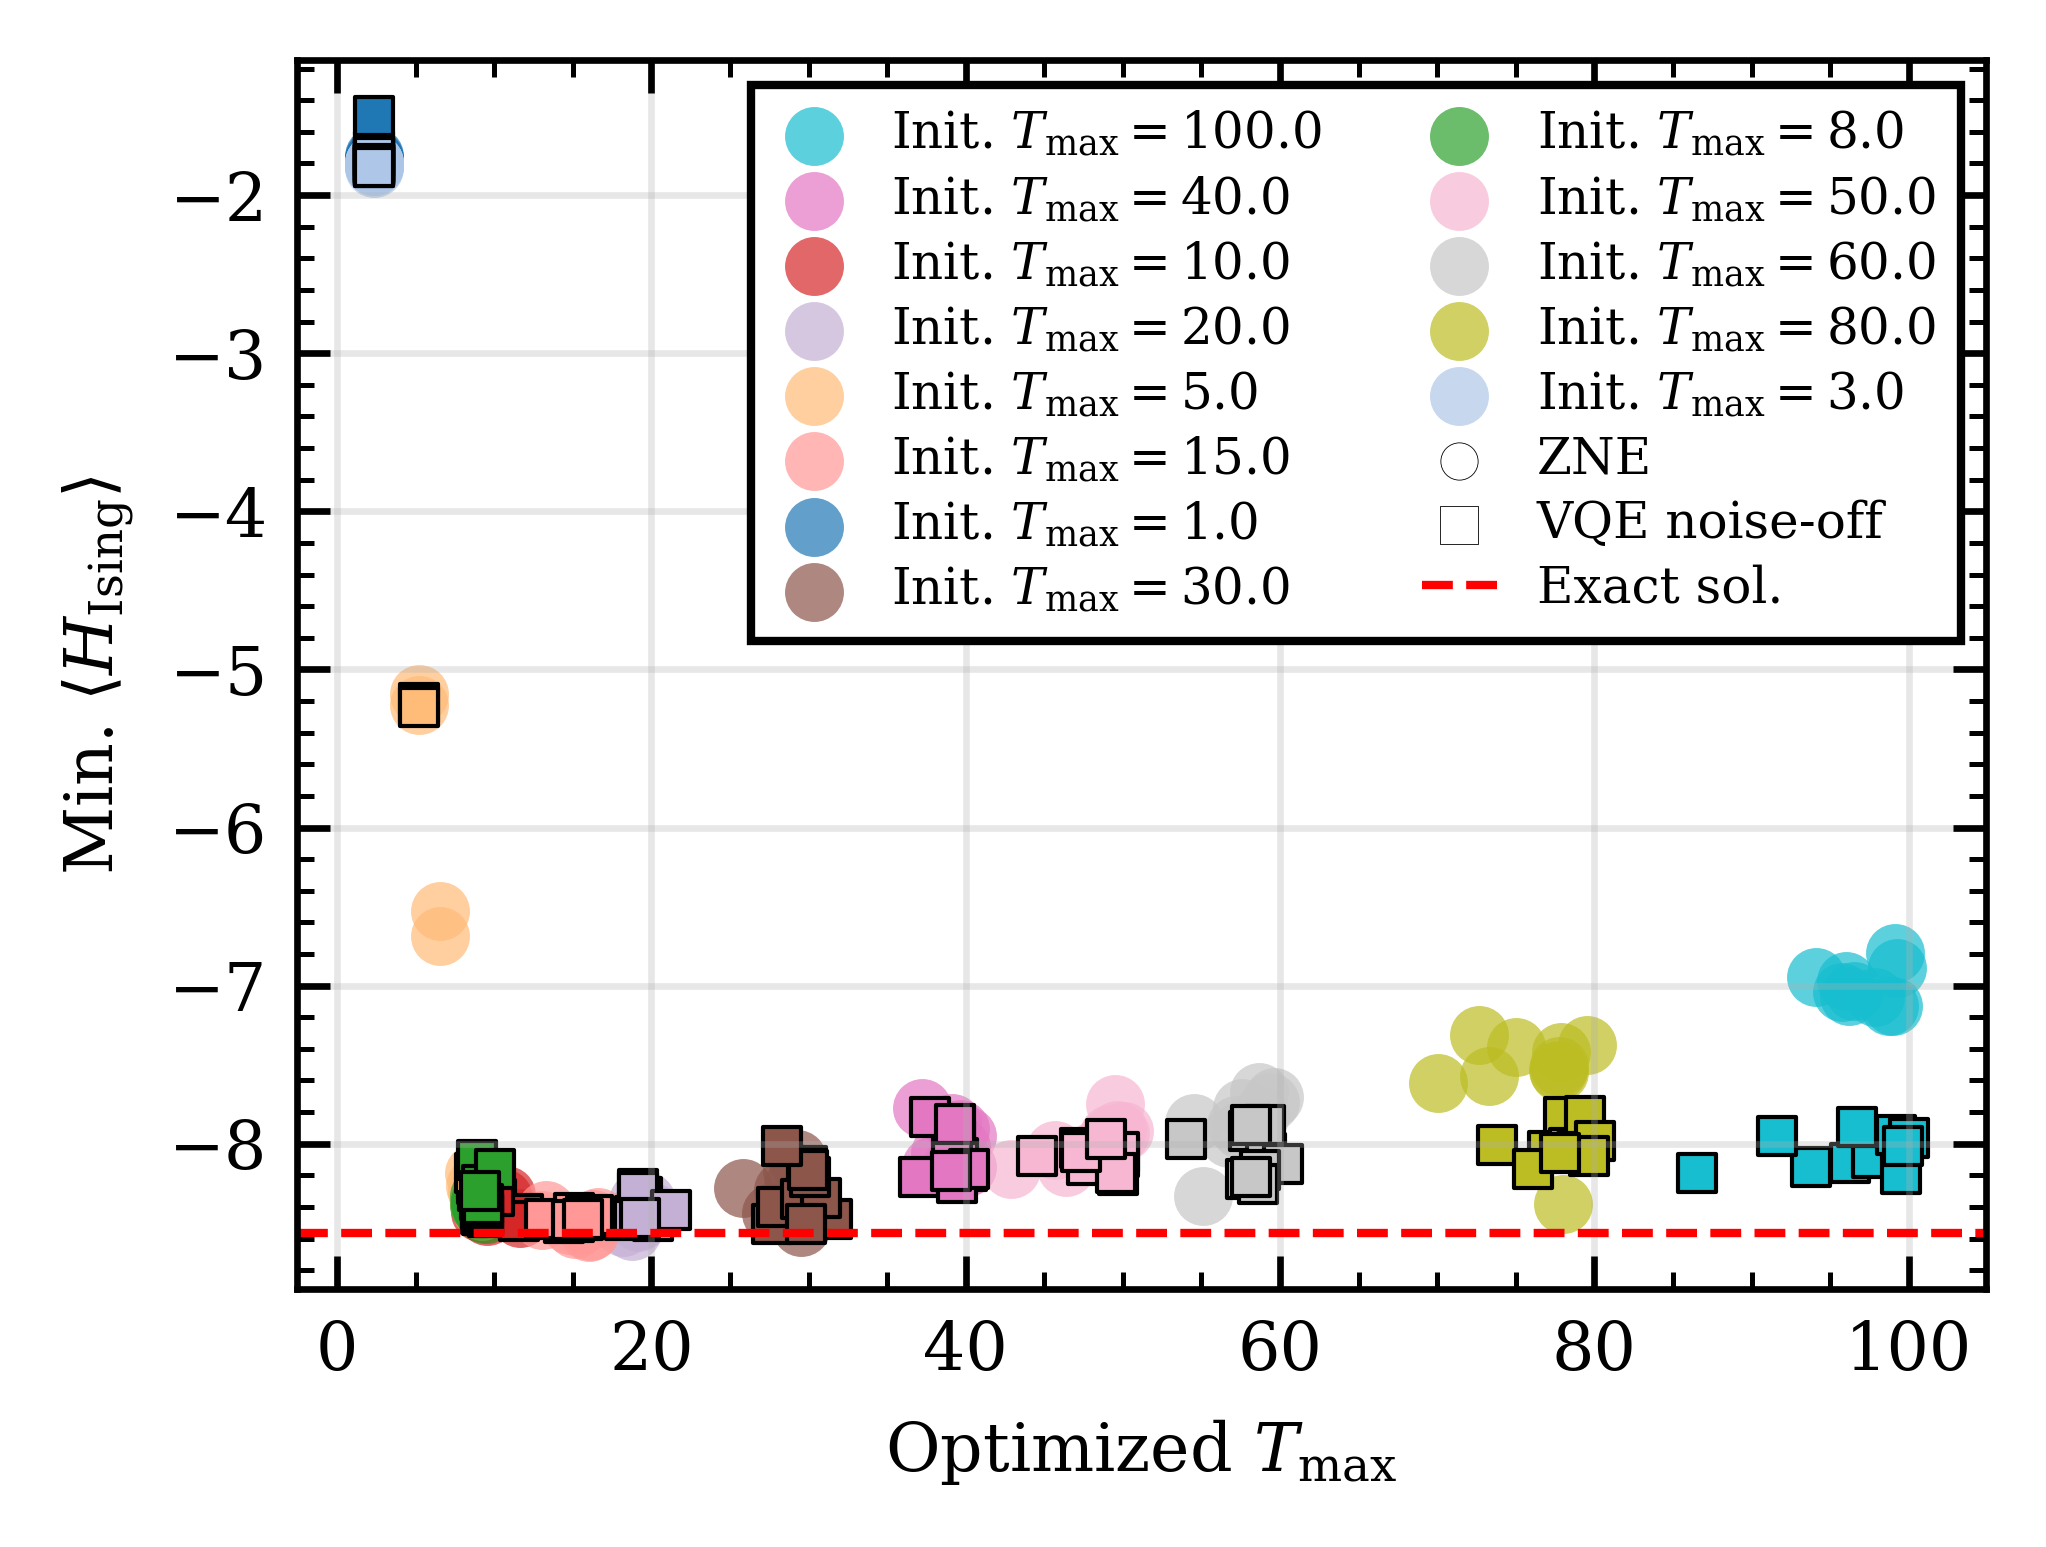

In [39]:
fig, ax = plt.subplots(figsize=FIG_SIZE_IEEE_DOUBLE)

# Color map only for ZNE (keyed by initial_tmax)
all_tmaxes = sorted(set(
    [data.get("initial_tmax") for labels in RAW_ZNE_VS_TMAX_DATA.values() for data in labels.values()]
) - {None})

cmap   = plt.cm.tab20
colors = {t: cmap(i / len(all_tmaxes)) for i, t in enumerate(all_tmaxes)}

NOISEOFF_COLOR = "black"

# --- ZNE (circles) ---
plotted_zne = set()
for exp_name, labels in RAW_ZNE_VS_TMAX_DATA.items():
    for label, data in labels.items():
        t = data.get("initial_tmax")
        ax.scatter(data["tmax_opt"], data["zne"],
                   color=colors[t], marker="o", s=50, alpha=0.7,
                   label=rf"Init. $T_{{\max}}={t}$" if t not in plotted_zne else "", edgecolors="black", linewidths=00)
        plotted_zne.add(t)

# --- VQE noise-off (stars, all same color) ---
for exp_name, data in RAW_NOISE_OFF_VQE_VS_TMAX_DATA.items():
    t = data.get("initial_tmax")
    ax.scatter(data["tmax_opt"], data["cost"],
               color=colors[t], marker="s", s=20, alpha=1.0, edgecolors="black", linewidths=0.5
               )

ax.axhline(-8.5668, color="red", linestyle="--", linewidth=1)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # one circle per initial_tmax from ZNE scatter

# Marker type explainers (grey, marker only)
by_label["ZNE"]       = ax.scatter([], [], marker="o", color="white", s=20,
                                           alpha=1.0, edgecolors="black", linewidths=0.1)
by_label["VQE noise-off"]  = ax.scatter([], [], marker="s", color="white", s=20,
                                           edgecolors="black", linewidths=0.1)
by_label["Exact sol."]       = Line2D([0],[0], color="red", linestyle="--", linewidth=1)

ax.legend(by_label.values(),
          by_label.keys(),
          loc="upper right",
          fontsize=6,
          ncol=2,
          framealpha=1.0,
          markerscale=1.0,
          handlelength=1.5,
          edgecolor="black",
          fancybox=False,
          borderpad=0.5,
          labelspacing=0.3)

ax.set_xlabel(r"Optimized $T_{\text{max}}$", fontsize=8)
ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"
ax.set_ylabel(ylabel)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MASTER_EXPORT_DIR, "VARIOUS-TMAX-IEEE.png"), dpi=600)
#plt.savefig(os.path.join(MASTER_EXPORT_DIR, "RAW-ZNE-VS-TMAX-SCATTER-IEEE.eps"), dpi=600)
plt.show()

---

## Plot: Singlevariate ZNE Plot For $T_{max}$=20

For `tmax=20` only

In [40]:
# Output directory to save plot figures
OUTPUT_DIR = "reports"
COLORS = {
    "noisy":      "#000000",
    "zne":        "#0000ff",
    "exact":      "#d62728",
    "noise_free": "#22c55e",
    "unmitigated": "#ff7f0e",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8
# Fig size
width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
#MASTER_EXPORT_DIR = "../master-reports/"
# (3.4133, 2.59) inches

In [41]:
# fig = plot_single_zne(
#     data=PROCESSED_SIM_DATA["tmax20"]["ric4"],
#     plot_colors=COLORS,
#     title_fontsize = TITLE_FONT_SIZE,
#     label_fontsize = LABEL_FONT_SIZE,
#     #tick_fontsize = TICK_FONT_SIZE,
#     legend_fontsize = LEGEND_FONT_SIZE,
#     #plot_title="ZNE – Depolarizing noise",
#     plot_file_name="zne_depol_noisy_evo_ric4",
#     output_dir=OUTPUT_DIR,
#     extrapol_target=0,
#     save_format="eps",
#     show_plot=True,
#     print_data=True,
#     figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
#     dpi=600,
# )

In [42]:
PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"]["ric3"]

{'noise_type': 'depolarizing',
 'tmax': 20.0,
 'exact_sol': -8.56677223350563,
 'order': 3,
 'sorted_noise': [1, 3, 5, 7],
 'mean_exp_vals': [-7.660840627906562,
  -6.293336422429532,
  -5.1833050438527,
  -4.28026529187638],
 'std_exp_vals': [0.0973059384114659,
  0.15411517524108667,
  0.18948092457375695,
  0.2090570610975394],
 'zne_mean': -8.4569204158263,
 'zne_std': 0.0598321278926665,
 'mean_noise_off': -8.414393509509072,
 'std_noise_off': 0.0720756358249069,
 'zne_cost_mean': 11.390625,
 'zne_cost_std': 0.0}

In [43]:
# pick which subcategories to include and in which order
subkeys = [ "ric6", "ric5", "ric4", "ric3", "ric2", "ric1"]  # or specify a subset like ["ric2", "ric3", "ric4", "ric5", "ric6"]

data_list   = [PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"][k] for k in subkeys]
plot_titles = subkeys   # or any custom labels you want per panel

# fig = plot_multi_zne(
#     data_list             = data_list,
#     #plot_titles           = subkeys,
#     sharex                = True,
#     plot_colors           = COLORS,
#     xlabel = None,
#     ylabel = "Expectation value",
#     title_fontsize        = TITLE_FONT_SIZE,
#     label_fontsize        = LABEL_FONT_SIZE,
#     tick_fontsize         = TICK_FONT_SIZE,
#     legend_fontsize       = LEGEND_FONT_SIZE-1,
#     marker_size           = 3,
#     capsize               = 2,
#     plot_file_name        = "xy-depol-diff-orders",
#     output_dir            = OUTPUT_DIR,
#     plot_titles           = [ "ric-7","ric-6", "ric-5", "ric-4", "ric-3", "ric-2"],
#     #panel_label_y         = -0.20,
#     ncols                 = 3,
#     figsize               = (3.45, 3.5),
#     dpi                   = 600,
#     sharey                = True,
#     show_legend           = True,
#     global_legend         = True,
#     legend_loc            = "upper center",
#     #legend_bbox           = (0.5, 0.95),
#     legend_ncols          = 2,
#     subplot_top           = 0.82,
#     subplot_bottom        = 0.18,
#     save_format           = "eps",
#     show_plot             = True,
#     print_data             = True,
# )

---

## Plot of ZNE of Different Orders for $T_{max} = 20$

### Main Result

✅ Saved: reports/7Q-various-tmax/RESULT-SINGLE-RIC-ZNE-VS-ORDER-IEEE.png


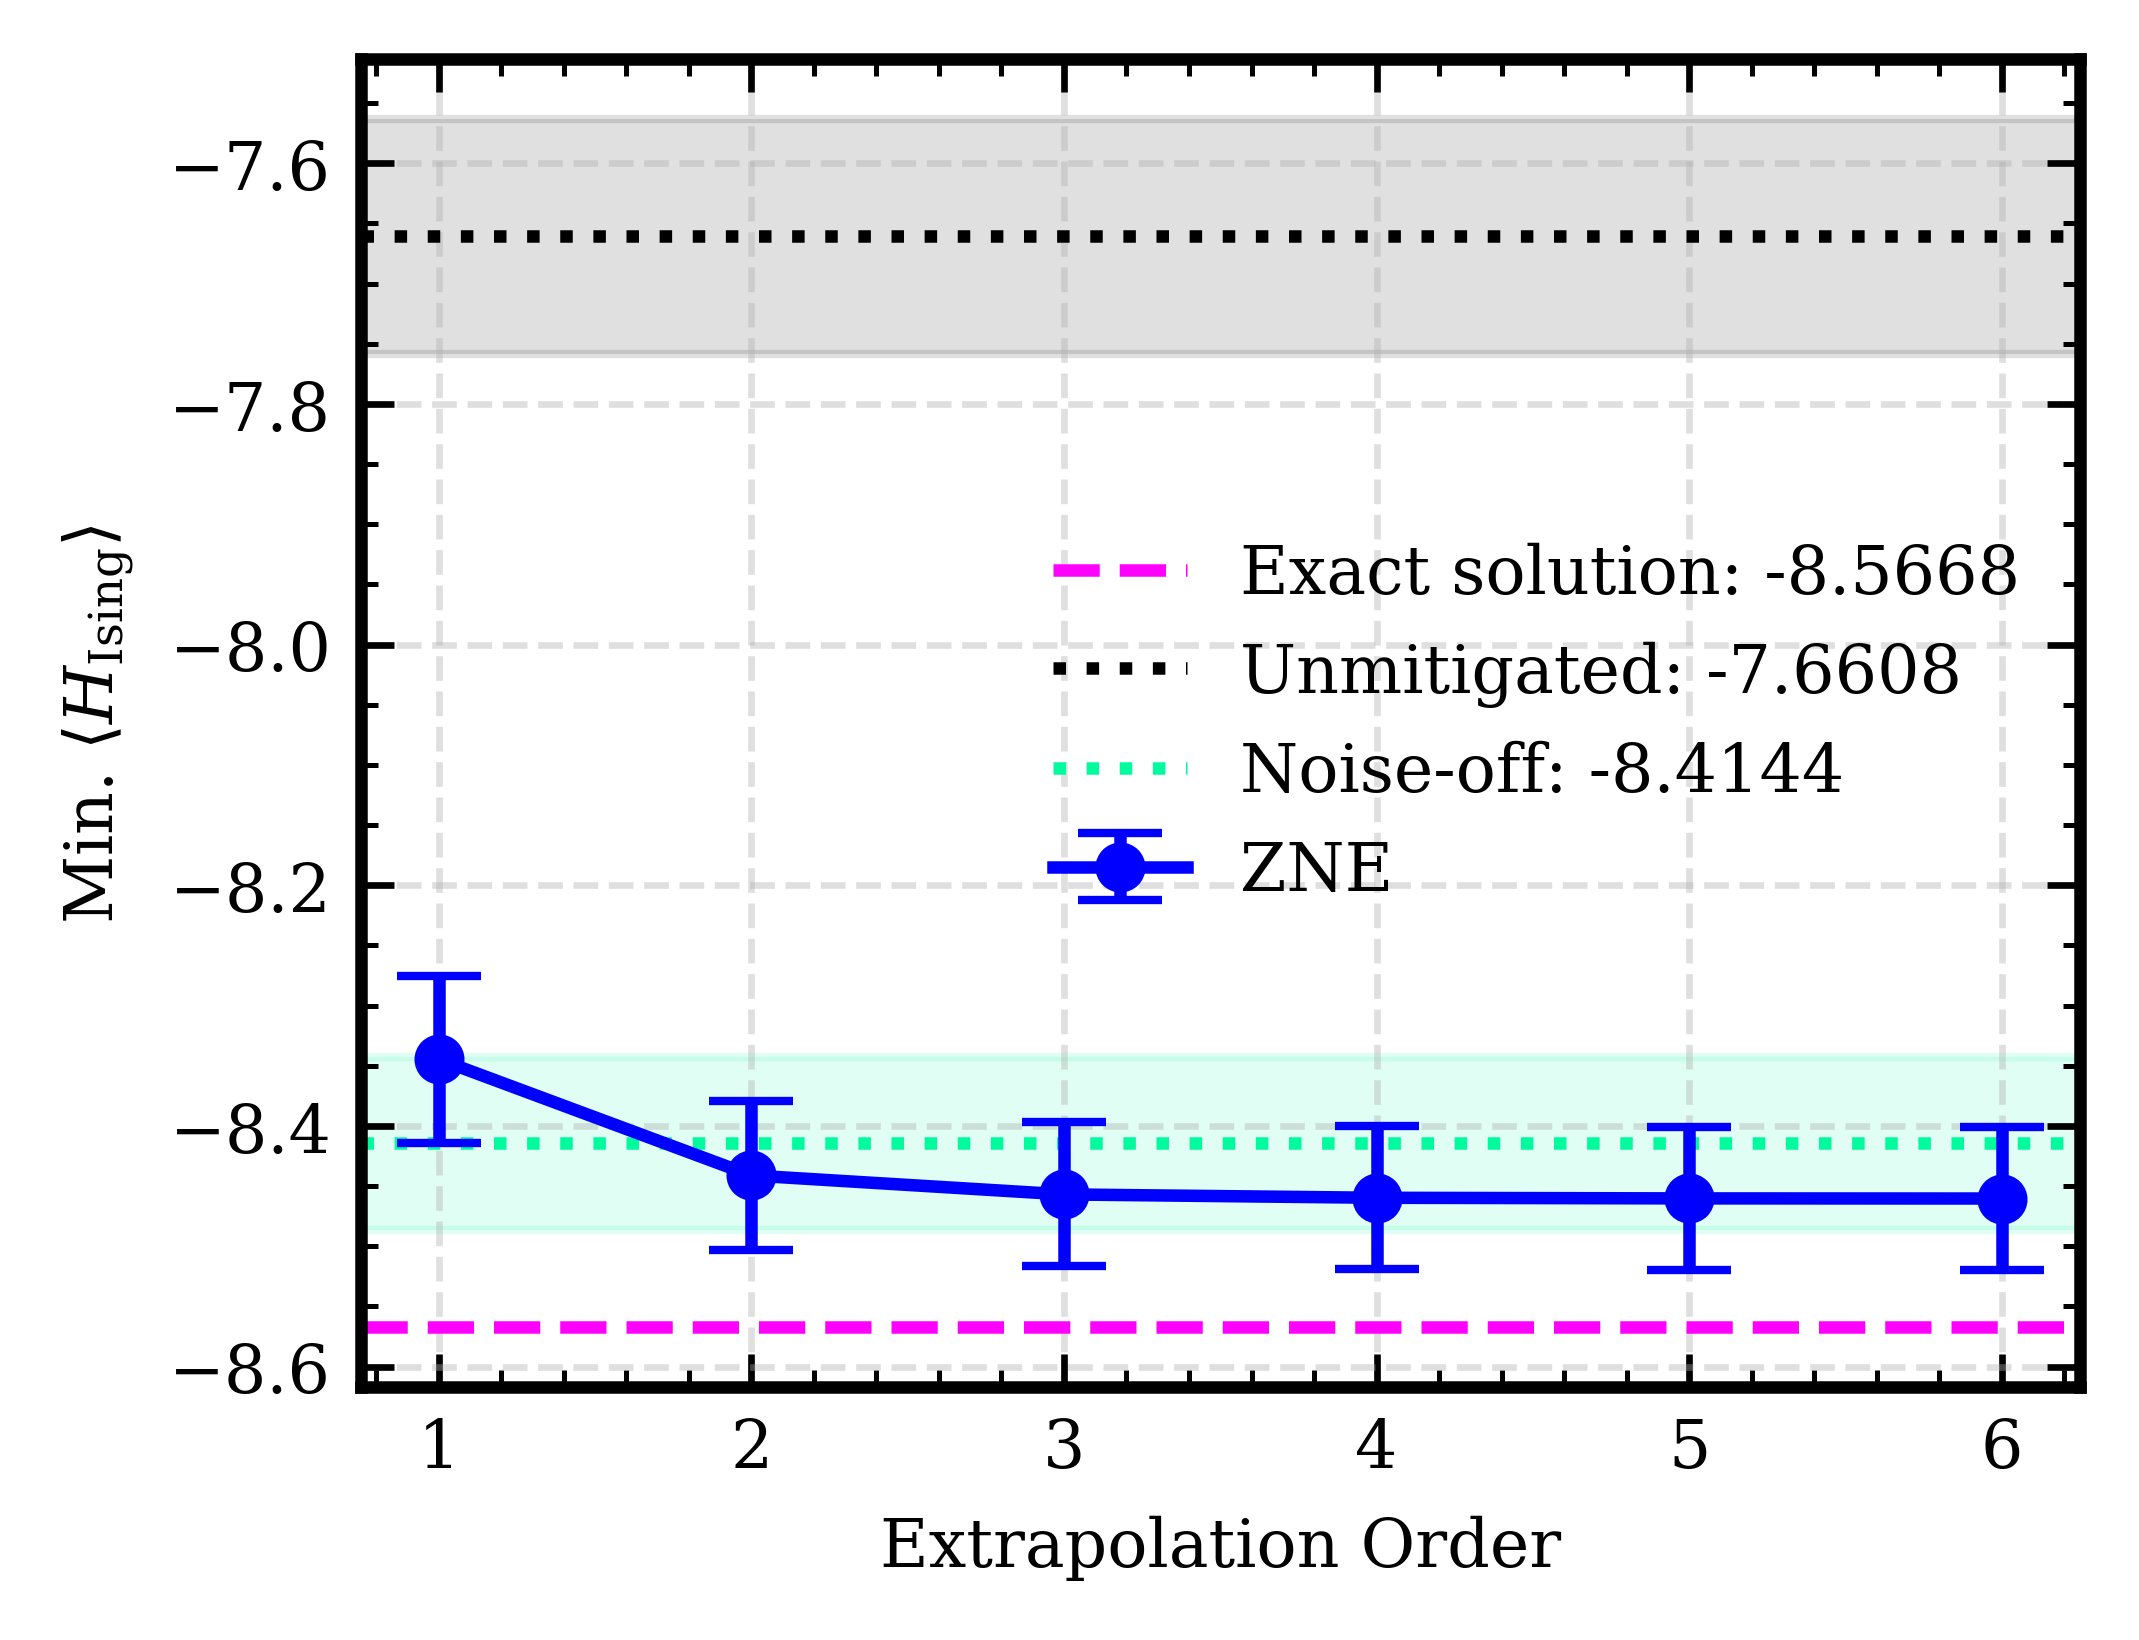

In [44]:
fig = ric_plot_zne_vs_degree(
    DATA=PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"],
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name="RESULT-SINGLE-RIC-ZNE-VS-ORDER-IEEE",
    output_dir=MASTER_EXPORT_DIR,
    save_format="png",
    show_plot=True,
    annotate_values = False,
    dpi                   = 600,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    marker_size           = 5,
    capsize               = 5,
    ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"

)

✅ Saved: reports/7Q-various-tmax/RESULT-SINGLE-RIC-ZNE-VS-ORDER-IEEE_SINGLE_COL.png


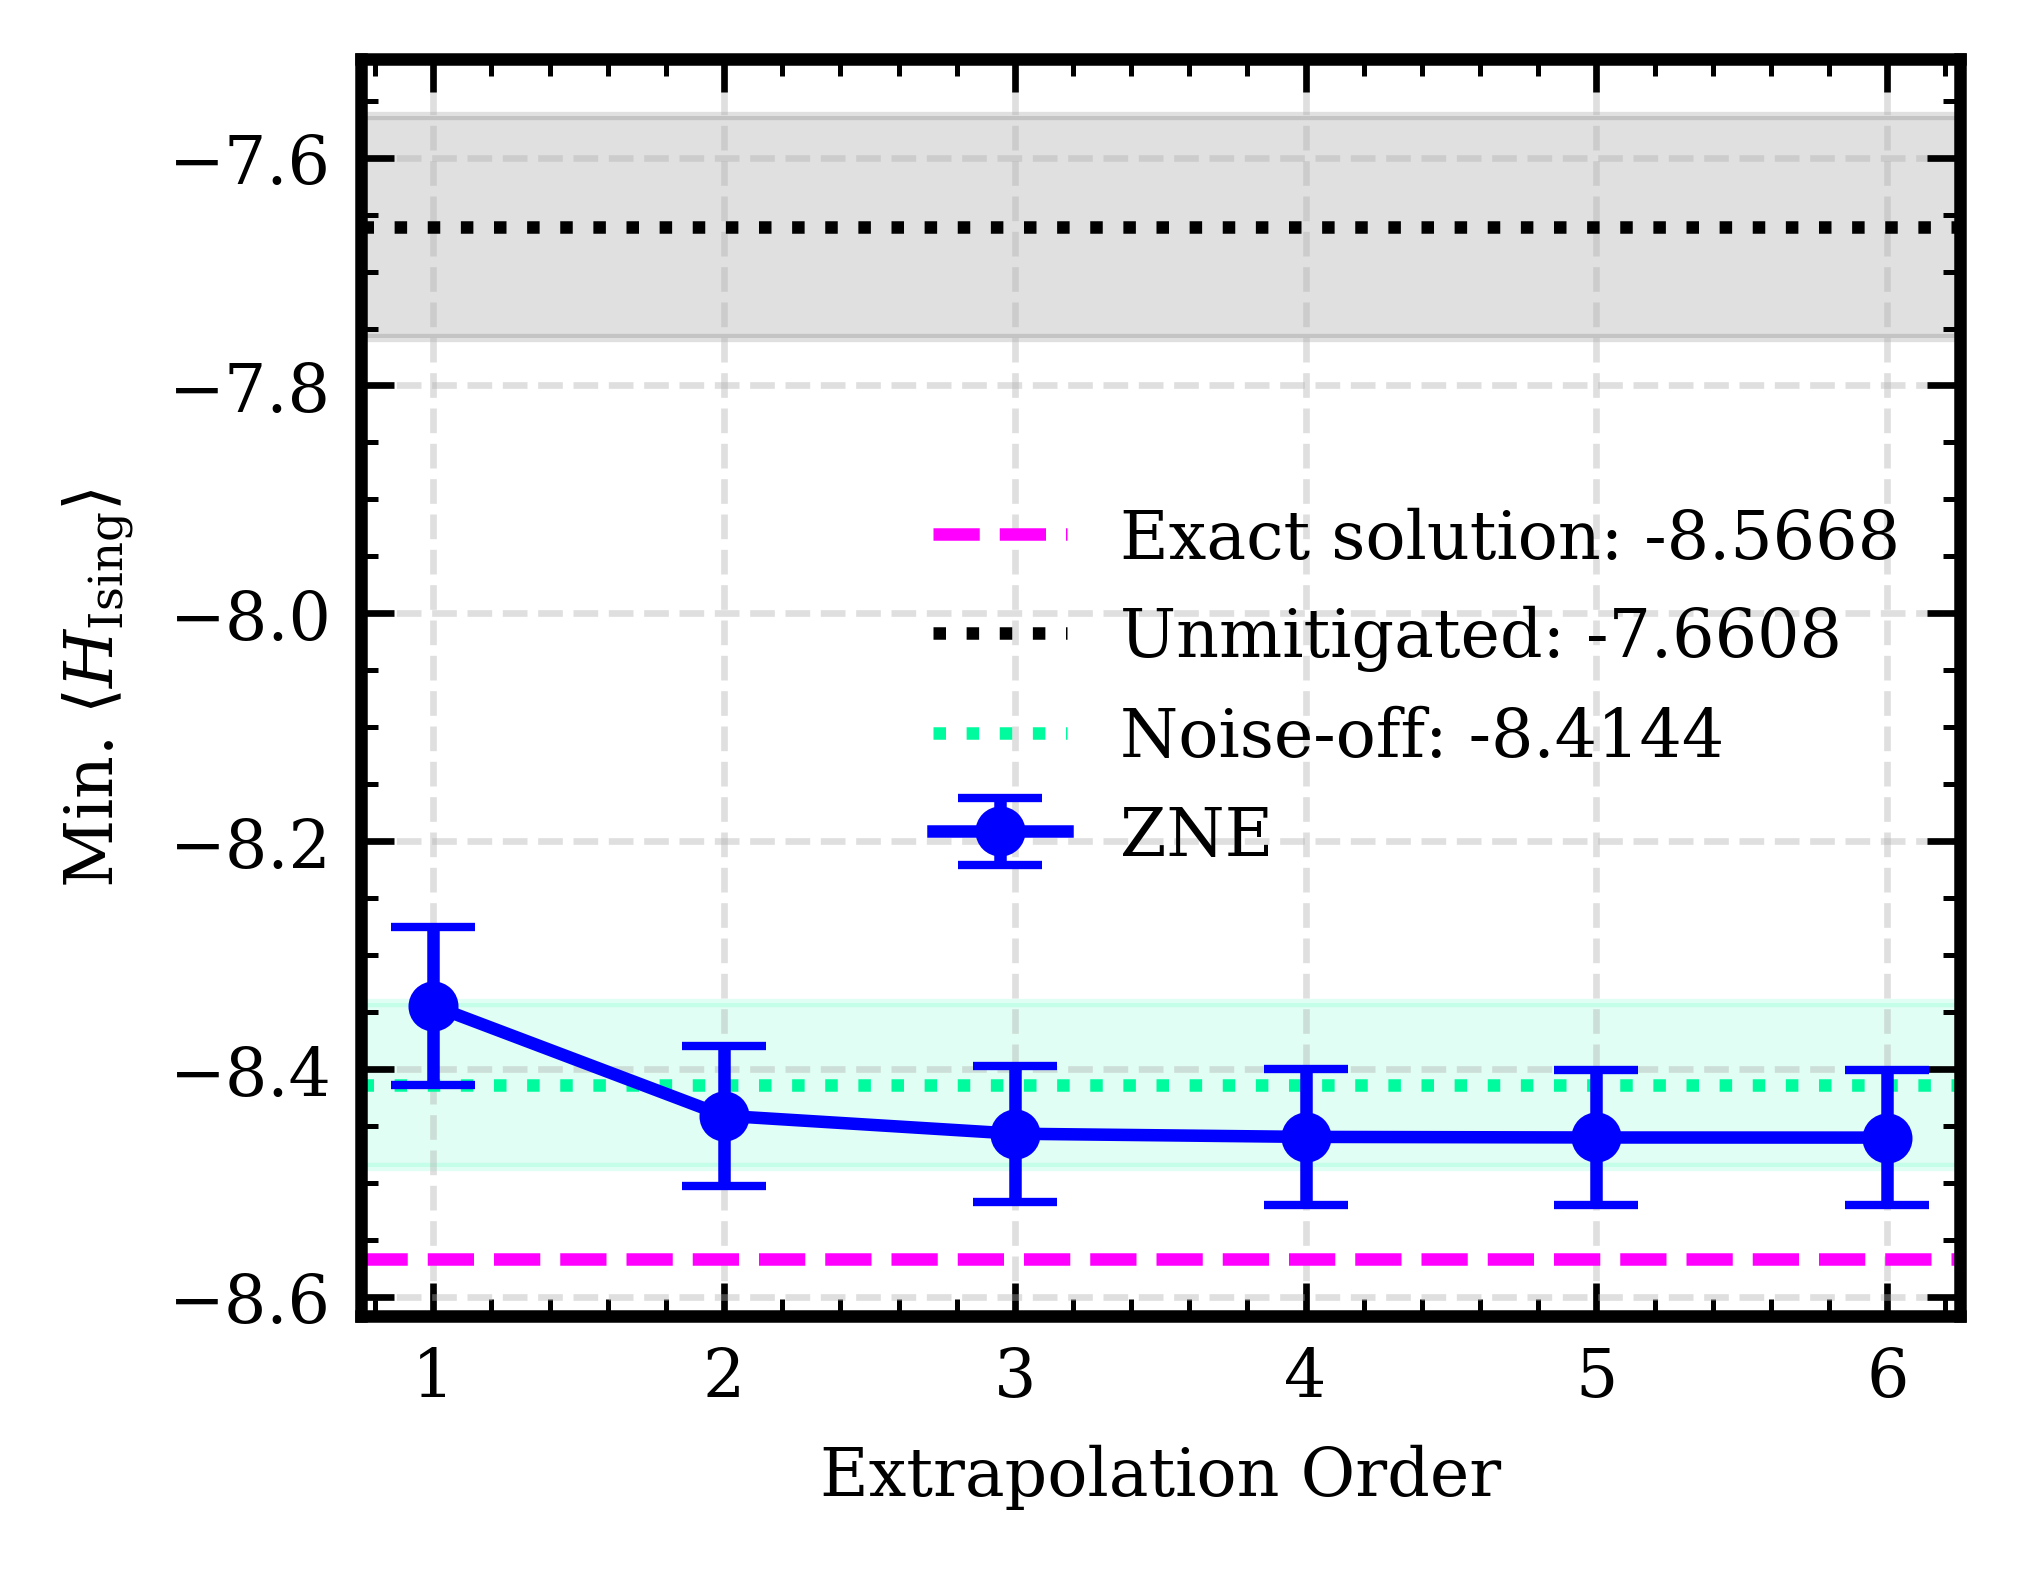

In [45]:
fig = ric_plot_zne_vs_degree(
    DATA=PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"],
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name="RESULT-SINGLE-RIC-ZNE-VS-ORDER-IEEE_SINGLE_COL",
    output_dir=MASTER_EXPORT_DIR,
    save_format="png",
    show_plot=True,
    annotate_values = False,
    dpi                   = 600,
    figsize               = (3.25, 2.5),
    marker_size           = 5,
    capsize               = 5,
    ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"

)

---

# Latex tools for Table

In [46]:

# ── Helper: convert PROCESSED_SIM_DATA → ordered list ────────────────────────
def build_data_list(processed_sim_data: dict) -> list:
    """
    Converts PROCESSED_SIM_DATA["ZNE-single-var"] into the flat list expected
    by make_zne_table(), ordered from most noise levels (ric7) to fewest (ric2).
    """
    zne_data = processed_sim_data["ZNE-single-var"]
    keys_sorted = sorted(
        zne_data.keys(),
        key=lambda k: len(zne_data[k]["sorted_noise"]),
        reverse=True,
    )
    return [zne_data[k] for k in keys_sorted]


# ── Core table function ───────────────────────────────────────────────────────
def make_zne_table(
    data_list: list,
    fig_width: float,          # final rendered width in inches — required
    dpi: int,                  # output DPI — required
    output_dir: str = "reports",
    filename_stem: str = "zne_table",
    row_height: float = 0.28,  # inches per row; tune to control table height
    fontsize: float = 8,
    save_eps: bool = True,
    save_png: bool = True,
) -> plt.Figure:
    """
    Parameters
    ----------
    data_list : list of dicts
        Each dict must contain:
            sorted_noise   – list of noise levels used
            mean_exp_vals  – list of mean expectation values per noise level
            std_exp_vals   – list of std dev per noise level
            zne_mean       – ZNE extrapolated mean
            zne_std        – ZNE extrapolated std
            mean_noise_off – noise-free estimation mean
            std_noise_off  – noise-free estimation std
        Ordered from most noise levels (ric7) to fewest (ric2).
    fig_width : float
        Final rendered figure width in inches (strictly honoured).
    dpi : int
        Output DPI (strictly honoured). Also sets rcParams for display.
    output_dir : str
        Directory to write output files.
    filename_stem : str
        Base filename without extension.
    row_height : float
        Height of each table row in inches.
    fontsize : float
        Font size for all table text (points).
    save_eps : bool
    save_png : bool

    Returns
    -------
    matplotlib Figure
    """

    # ── Reference entry: most noise levels (first in list) ───────────────────
    ref = data_list[0]

    # ── Build row labels and value strings ────────────────────────────────────
    row_labels = []
    row_values = []

    # Section 1 – Noise-free
    row_labels.append("Noise-free estimation")
    row_values.append(
        f"{ref['mean_noise_off']:.3f} \u00b1 {ref['std_noise_off']:.3f}"
    )

    # Section 2 – Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = ("Base noise=" + str(noise_val)) if idx == 0 else ("Boosted noise=" + str(noise_val))
        row_labels.append(label)
        row_values.append(f"{mean_val:.3f} \u00b1 {std_val:.3f}")

    # Section 3 – ZNE values, 2-point → N-point
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        row_labels.append(f"{n_pts}-point Richardson (ric-{n_pts}) ZNE value")
        row_values.append(f"{entry['zne_mean']:.3f} \u00b1 {entry['zne_std']:.3f}")

    # ── Section divider positions ─────────────────────────────────────────────
    n_noise_rows   = len(ref["sorted_noise"])
    section_breaks = [1, 1 + n_noise_rows]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_rows = len(row_labels)
    fig_h  = n_rows * row_height

    matplotlib.rcParams["figure.dpi"] = dpi

    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows)

    # Remove all automatic padding — preserves exact figsize on save.
    # Do NOT use bbox_inches="tight" in savefig; it resizes the canvas.
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    PAD_L = 0.012
    PAD_R = 0.012

    # ── Draw rows ─────────────────────────────────────────────────────────────
    for i, (label, value) in enumerate(zip(row_labels, row_values)):
        y_center = n_rows - i - 0.5
        bold     = (i == 0)

        ax.text(
            PAD_L, y_center, label,
            va="center", ha="left",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )
        ax.text(
            1 - PAD_R, y_center, value,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )

    # ── Horizontal rules ──────────────────────────────────────────────────────
    ax.axhline(n_rows, color="black", lw=1.0)
    ax.axhline(0,      color="black", lw=1.0)
    for sb in section_breaks:
        ax.axhline(n_rows - sb, color="black", lw=0.6)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(output_dir, exist_ok=True)

    if save_eps:
        eps_path = os.path.join(output_dir, f"{filename_stem}.eps")
        fig.savefig(eps_path, format="eps", dpi=dpi)
        print(f"Saved EPS → {eps_path}  |  width={fig.get_figwidth():.3f} in  dpi={dpi}")

    if save_png:
        png_path = os.path.join(output_dir, f"{filename_stem}.png")
        fig.savefig(png_path, format="png", dpi=dpi)
        from PIL import Image
        img = Image.open(png_path)
        print(
            f"Saved PNG → {png_path}  |  "
            f"{img.size[0]}x{img.size[1]} px  "
            f"({img.size[0]/dpi:.3f} x {img.size[1]/dpi:.3f} in at {dpi} dpi)"
        )
    plt.close(fig)
    # ── Generate LaTeX String ────────────────────────────────────────────────
    latex_lines = ["\\hline"]

    # Section 1: Noise-free
    latex_lines.append(
        f"        Noise-free estimation & ${ref['mean_noise_off']:.3f} \\pm {ref['std_noise_off']:.3f} $\\\\"
    )
    latex_lines.append("        \\hline")

    # Section 2: Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = "At base noise" if idx == 0 else "At boosted noise"
        latex_lines.append(
            f"        {label} $= {noise_val}$ & ${mean_val:.3f} \\pm {std_val:.3f} $\\\\"
        )
    latex_lines.append("        \\hline")

    # Section 3: ZNE Values (No bold)
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        label = f"ZNE of order {n_pts - 1}"
        val_str = f"{entry['zne_mean']:.3f} \\pm {entry['zne_std']:.3f}"
        latex_lines.append(f"        {label} & ${val_str}$ \\\\")
    latex_lines.append("        \\hline")

    # Join and print
    latex_output = "\n".join(latex_lines)
    print("\n--- LaTeX Table Code ---")
    print(latex_output)
    print("------------------------\n")

    # Optional: Save to .tex file
    with open(os.path.join(output_dir, f"{filename_stem}.tex"), "w") as f:
        f.write(latex_output)

    return fig

In [47]:
for entry in reversed(data_list):
    n_pts = len(entry["sorted_noise"])
    order = n_pts - 1
    cost = entry["zne_cost_mean"]
    print(f"ZNE order {order}: cost = {cost}")

ZNE order 1: cost = 2.5
ZNE order 2: cost = 5.21875
ZNE order 3: cost = 11.390625
ZNE order 4: cost = 27.5960693359375
ZNE order 5: cost = 74.27313232421875
ZNE order 6: cost = 217.1086845397951


Saved EPS → reports/zne-table-1.eps  |  width=3.500 in  dpi=600
Saved PNG → reports/zne-table-1.png  |  2100x1512 px  (3.500 x 2.520 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-8.414 \pm 0.072 $\\
        \hline
        At base noise $= 1$ & $-7.661 \pm 0.097 $\\
        At boosted noise $= 3$ & $-6.293 \pm 0.154 $\\
        At boosted noise $= 5$ & $-5.183 \pm 0.189 $\\
        At boosted noise $= 7$ & $-4.280 \pm 0.209 $\\
        At boosted noise $= 9$ & $-3.544 \pm 0.217 $\\
        At boosted noise $= 11$ & $-2.942 \pm 0.218 $\\
        At boosted noise $= 13$ & $-2.449 \pm 0.212 $\\
        \hline
        ZNE of order 1 & $-8.345 \pm 0.070$ \\
        ZNE of order 2 & $-8.441 \pm 0.062$ \\
        ZNE of order 3 & $-8.457 \pm 0.060$ \\
        ZNE of order 4 & $-8.460 \pm 0.059$ \\
        ZNE of order 5 & $-8.460 \pm 0.059$ \\
        ZNE of order 6 & $-8.460 \pm 0.059$ \\
        \hline
------------------------



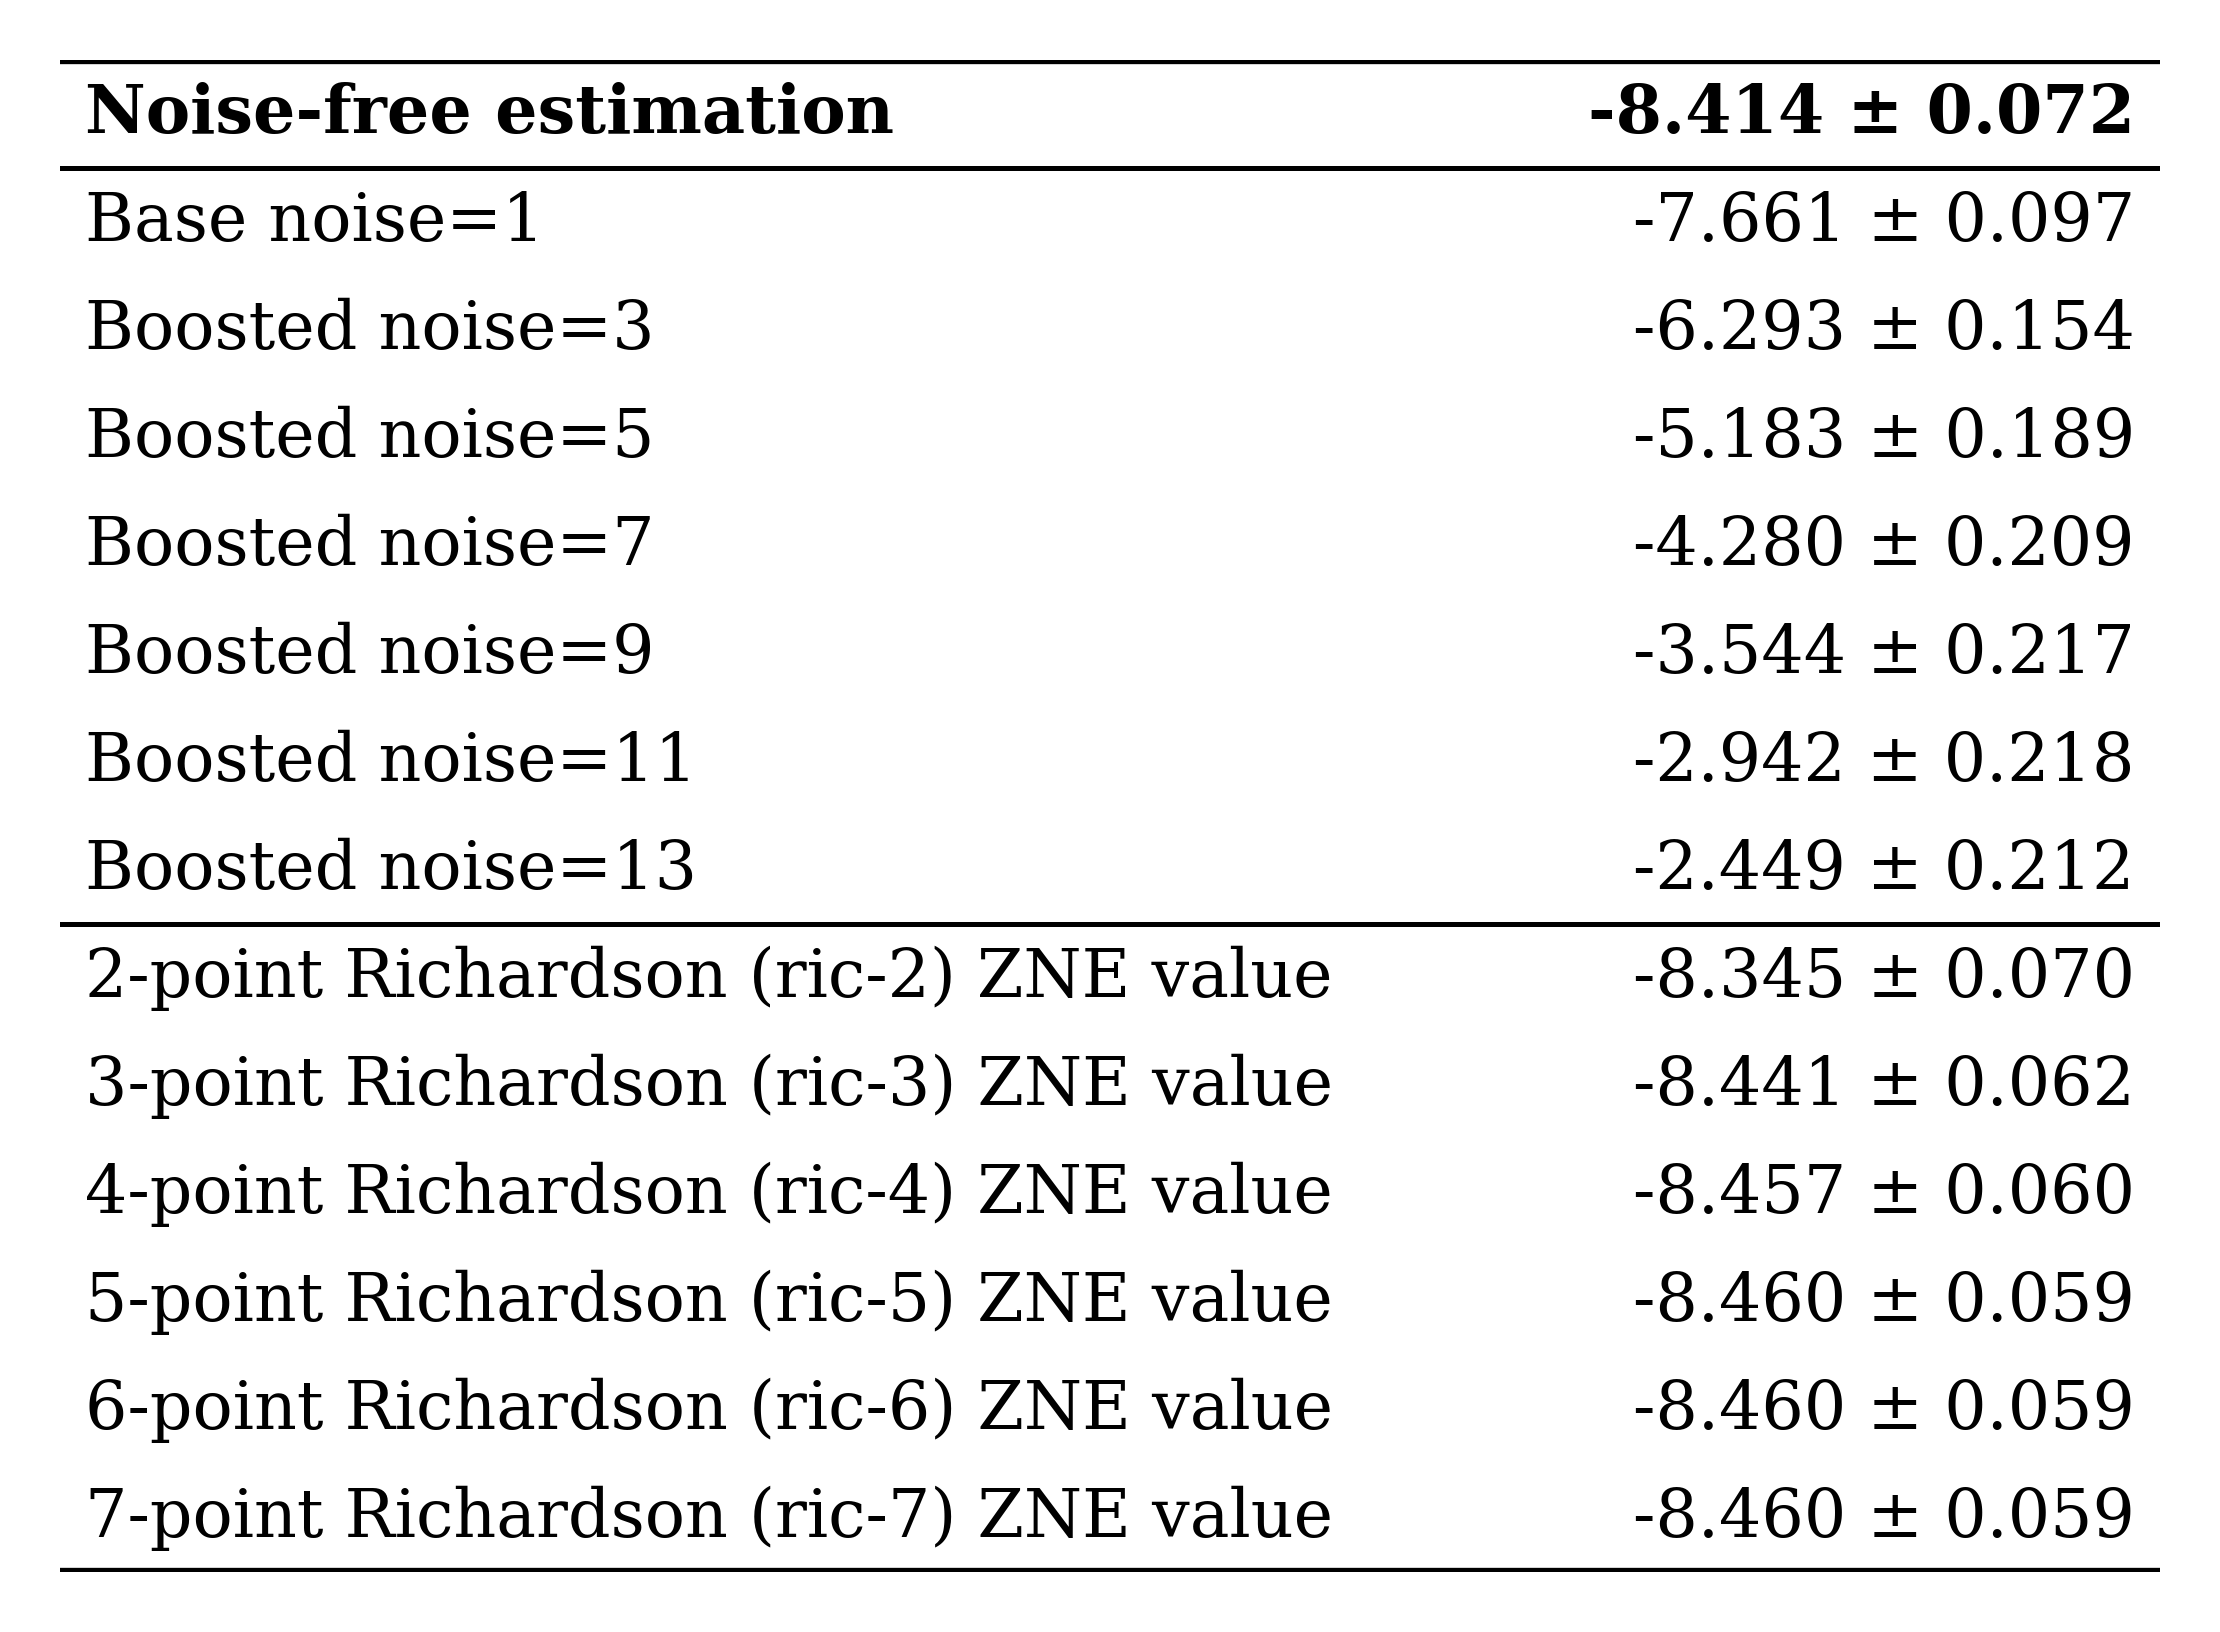

In [48]:
make_zne_table(data_list, output_dir=OUTPUT_DIR, filename_stem="zne-table-1", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

---

# ZNE Cost Overhead

In [49]:
PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"]["ric4"]

{'noise_type': 'depolarizing',
 'tmax': 20.0,
 'exact_sol': -8.56677223350563,
 'order': 4,
 'sorted_noise': [1, 3, 5, 7, 9],
 'mean_exp_vals': [-7.6608406279065635,
  -6.293336422429533,
  -5.183305043852699,
  -4.28026529187638,
  -3.543946126834258],
 'std_exp_vals': [0.0973059384114659,
  0.15411517524108667,
  0.18948092457375695,
  0.20905706109753938,
  0.2173090499816323],
 'zne_mean': -8.459712256624485,
 'zne_std': 0.059429960033808245,
 'mean_noise_off': -8.414393509509072,
 'std_noise_off': 0.0720756358249069,
 'zne_cost_mean': 27.5960693359375,
 'zne_cost_std': 0.0}

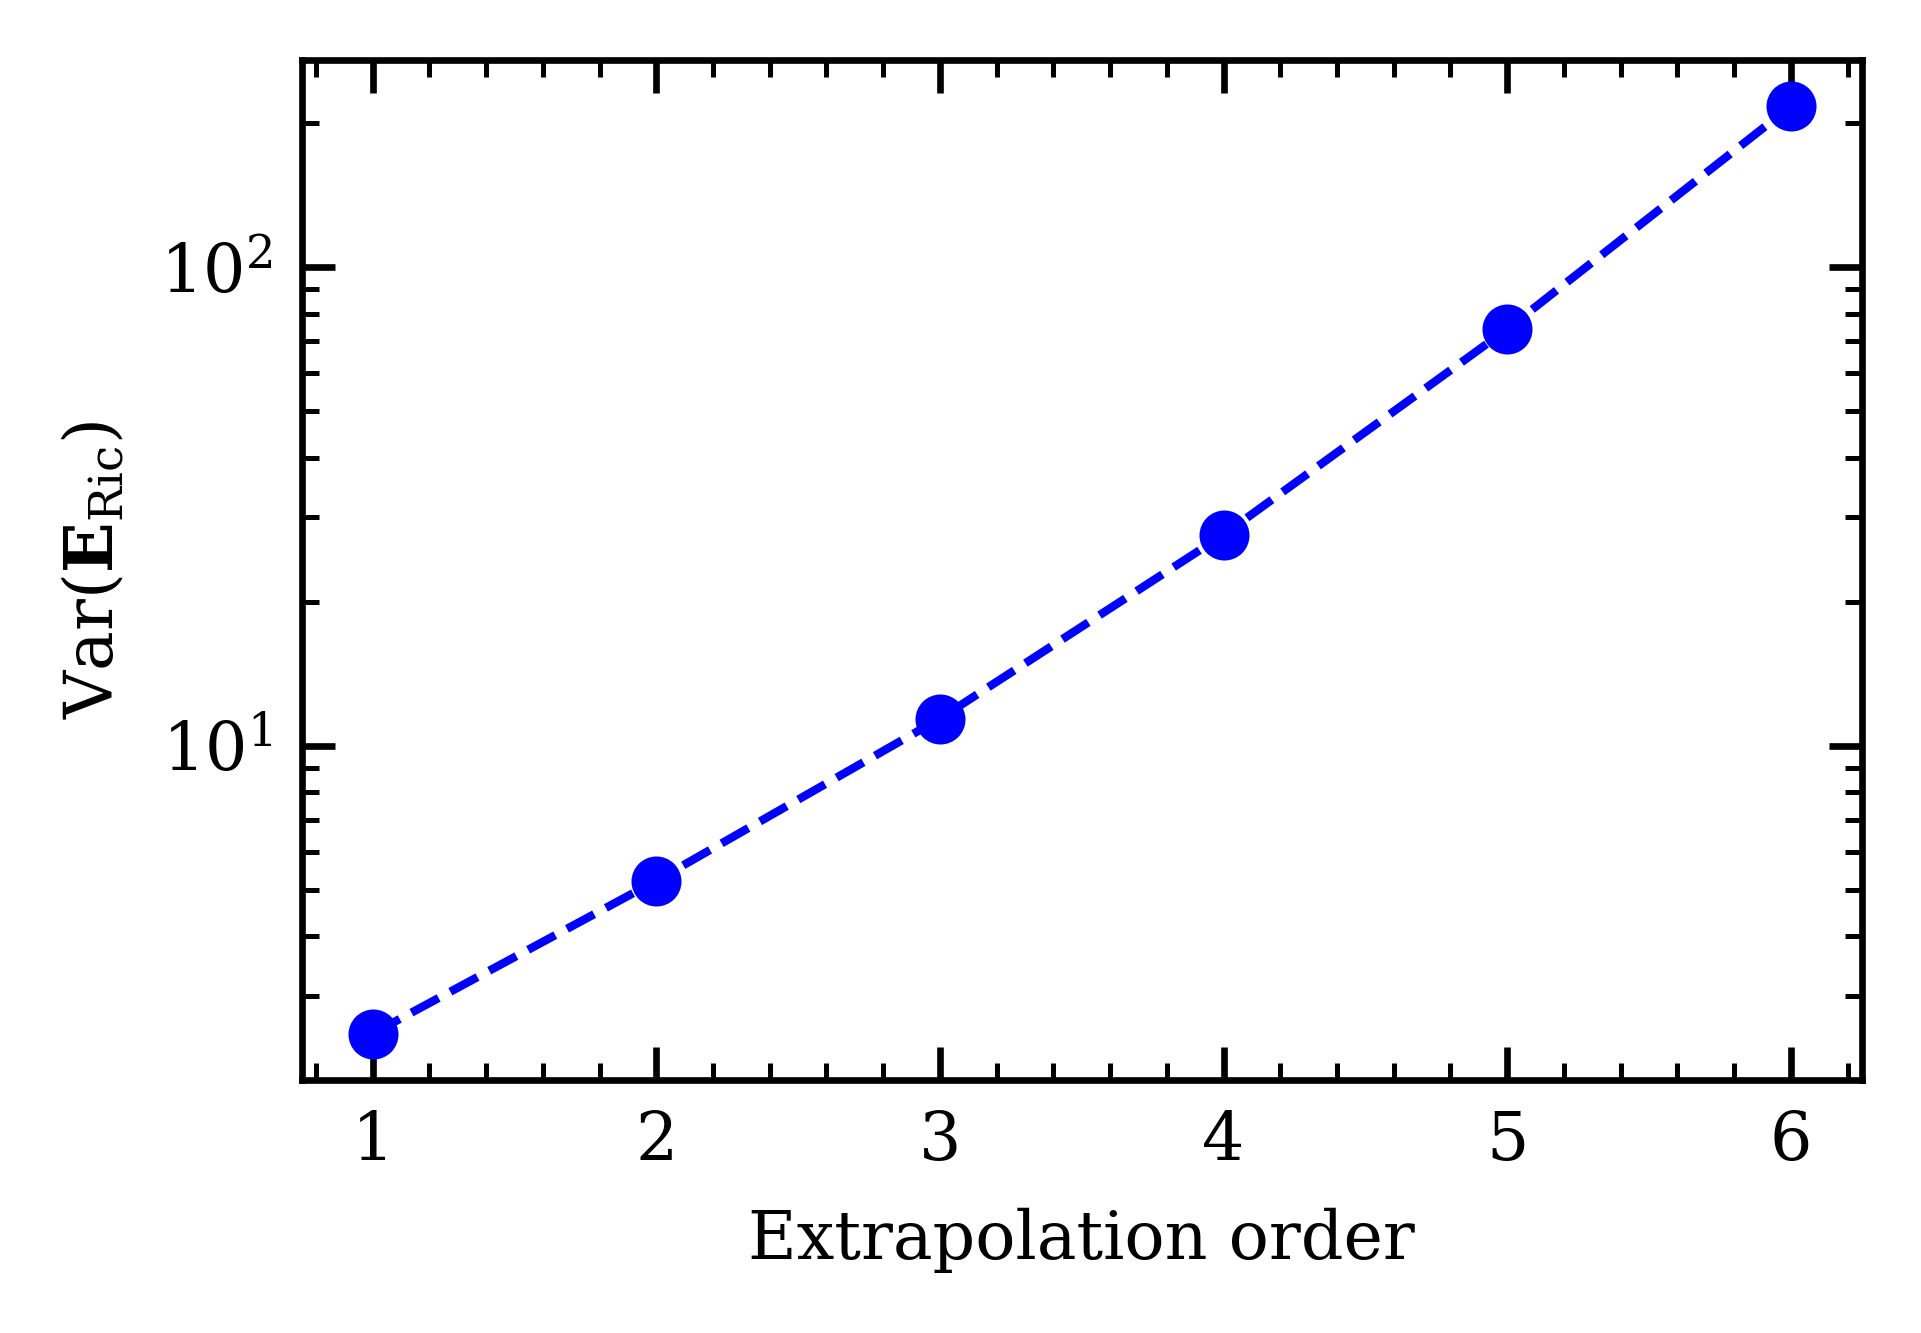

In [50]:
zne_cost_overhead = []
zne_cost_std = []
zne_order = []

# 1. Extract data using the correct key ["order"]
for item in PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"]:
    zne_cost_overhead.append(PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"][item]["zne_cost_mean"])
    zne_cost_std.append(PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"][item]["zne_cost_std"])
    zne_order.append(PROCESSED_SIM_DATA["7Q_tmax_sweep_ising_depol_tmax20_20260725_110811"][item]["order"])

# 2. Include zne_cost_std in the zip so all three arrays stay synchronized when sorted
sorted_data = sorted(zip(zne_order, zne_cost_overhead, zne_cost_std))
zne_order, zne_cost_overhead, zne_cost_std = zip(*sorted_data)

plt.figure(figsize=(3.25, 2.5))

# 3. Only use plt.errorbar (handles line, markers, and error bars together cleanly)
plt.errorbar(
    zne_order, zne_cost_overhead,
    fmt='o', linestyle='--', color='#0000ff', 
    linewidth=1, capsize=5, markersize=5
)

# 4. FIX: Make the Y-axis compact using a logarithmic scale
plt.yscale('log')

plt.xlabel('Extrapolation order', fontsize=8)
plt.ylabel(r'$\operatorname{Var}(\mathbf{E}_\text{Ric})$', fontsize=8)

# FIX: Set which='both' so the grid works seamlessly with major and minor log scale ticks
#plt.grid(True, linestyle='--', which='both', linewidth=0.5) 

plt.subplots_adjust(left=0.18, right=0.98, top=0.88, bottom=0.20)

#plt.title('Multi-Variate, All gates are noisy', fontsize=10)
# Ensure OUTPUT_DIR exists before saving
os.makedirs(MASTER_EXPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(MASTER_EXPORT_DIR, "cost_beta_ric3.png"), format="png", dpi=600)
plt.show()
plt.close()